In [1]:
import numpy as np
import pandas as pd
import create_synthetic_data as get_data
import matplotlib.pyplot as plt
from paretoset import paretoset
import PF_func_theoretic as func

In [2]:
# parameters for the population distributions
alpha0, beta0 = 4.5,5.5
alpha1, beta1 = 5, 3
N_0, N_1 = 5000, 5000     # population size
N = N_0 + N_1

# parameters for the utility functions 
u00, u01, u10, u11 = 0, 0, -0.5, 1
v00, v01, v10, v11 = 0, 0, -1, 1

# other parameters
fairness_metric = 'abs_delta_V'                                          
num_thresholds = 100  

In [3]:
data_distr = get_data.data_distribution(alpha0, beta0, alpha1, beta1, num_thresholds)
synth_data1 = data_distr.create_dataframe()

In [4]:
synth_data1.head()

,left_bound,right_bound,p_center,pop0,pop1
0,0.00,0.01,0.005,5.150636e-08,6.497039e-10
1,0.01,0.02,0.015,2.301677e-06,5.157352e-08
2,0.02,0.03,0.025,1.313932e-05,3.899048e-07
3,0.03,0.04,0.035,4.072612e-05,1.467290e-06
4,0.04,0.05,0.045,9.365285e-05,3.926866e-06


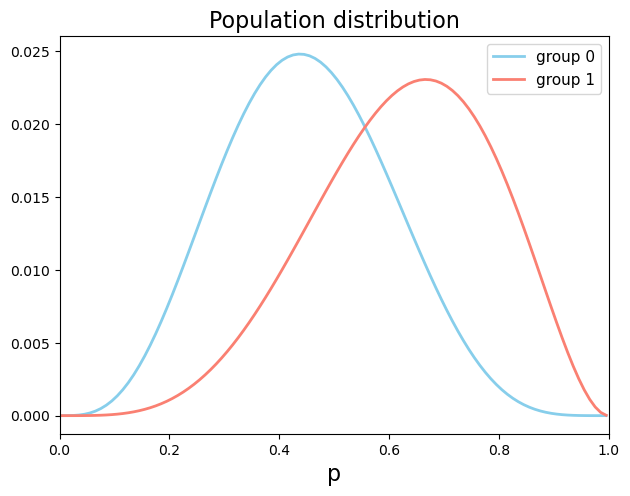

In [5]:
##PLOT DISTRIBUTION
plt.plot(synth_data1.p_center,synth_data1['pop0'], color = 'skyblue', label = 'group 0',lw=2)
plt.plot(synth_data1.p_center,synth_data1['pop1'], color = 'salmon', label = 'group 1',lw=2)
plt.xlim(0,1)
plt.xlabel('p', fontsize=16)
plt.tight_layout()
plt.legend(fontsize=11)
plt.title('Population distribution', fontsize=16)
plt.show()

In [6]:
##EVALUATE DATA
run_pf = func.pareto_front_theoretic(u00,u01,u10,u11,v00,v01,v10,v11,num_thresholds,N_0,N_1,N)
x = np.linspace(0, 1, num_thresholds + 1)
# determine U and V for two groups 0 and 1 for each threshold
lb_U = {}
lb_V = {}
ub_U = {}
ub_V = {}
for a in [0,1]:
    col = f'pop{a}'
    lb_U[a] = {}
    lb_V[a] = {}
    ub_U[a] = {}
    ub_V[a] = {}
    for t in x:
        U_avg_lb, V_avg_lb = run_pf.evaluate_threshold_lb(synth_data1, t, col)
        U_avg_ub, V_avg_ub = run_pf.evaluate_threshold_ub(synth_data1, t, col)
        lb_U[a][t] = U_avg_lb
        lb_V[a][t] = V_avg_lb
        ub_U[a][t] = U_avg_ub
        ub_V[a][t] = V_avg_ub

In [7]:
# deterministic group dependend lower-bound threshold rules
results_lb_lb = []
results_ub_ub = []
results_lb_ub = []
results_ub_lb = []
for t_0 in x:
    for t_1 in x:
        results_lb_lb.append({
            't_0': t_0,
            't_1': t_1,
            'U_tot': lb_U[0][t_0]*N_0 + lb_U[1][t_1]*N_1,
            'U_avg': (lb_U[0][t_0]*N_0 + lb_U[1][t_1]*N_1) / N,
            'FS' : run_pf.fairness_score_utility_space(lb_V[0][t_0],lb_V[1][t_1], fairness_metric),
            'rule': 'lb_lb'
            })
        results_ub_ub.append({
            't_0': t_0,
            't_1': t_1,
            'U_tot': ub_U[0][t_0]*N_0 + ub_U[1][t_1]*N_1,
            'U_avg': (ub_U[0][t_0]*N_0 + ub_U[1][t_1]*N_1) / N,
            'FS' : run_pf.fairness_score_utility_space(ub_V[0][t_0],ub_V[1][t_1], fairness_metric),
            'rule': 'ub_ub'
            })
        results_lb_ub.append({
            't_0': t_0,
            't_1': t_1,
            'U_tot': lb_U[0][t_0]*N_0 + ub_U[1][t_1]*N_1,
            'U_avg': (lb_U[0][t_0]*N_0 + ub_U[1][t_1]*N_1) / N,
            'FS' : run_pf.fairness_score_utility_space(lb_V[0][t_0],ub_V[1][t_1], fairness_metric),
            'rule': 'lb_ub'
            })
        results_ub_lb.append({
            't_0': t_0,
            't_1': t_1,
            'U_tot': ub_U[0][t_0]*N_0 + lb_U[1][t_1]*N_1,
            'U_avg': (ub_U[0][t_0]*N_0 + lb_U[1][t_1]*N_1) / N,
            'FS' : run_pf.fairness_score_utility_space(ub_V[0][t_0],lb_V[1][t_1], fairness_metric),
            'rule': 'ub_lb'
            })


In [8]:
results_all = results_lb_lb + results_ub_ub + results_lb_ub + results_ub_lb
df_results = pd.DataFrame(results_all)

## GET PARETO FRONT
# pareto front for deterministic lower-bound shared threshold rule
mask_all = paretoset(df_results[['U_avg','FS']], sense=['max','min'])
df_paretoset_all = df_results[mask_all].sort_values(by='U_avg')

mask_lb_lb = paretoset(df_results[df_results.rule =='lb_lb'][['U_avg','FS']], sense=['max','min'])
df_paretoset_lb_lb = df_results[df_results.rule =='lb_lb'][mask_lb_lb].sort_values(by='U_avg')

mask_ub_ub = paretoset(df_results[df_results.rule =='ub_ub'][['U_avg','FS']], sense=['max','min'])
df_paretoset_ub_ub = df_results[df_results.rule =='ub_ub'][mask_ub_ub].sort_values(by='U_avg')

mask_lb_ub = paretoset(df_results[df_results.rule =='lb_ub'][['U_avg','FS']], sense=['max','min'])
df_paretoset_lb_ub = df_results[df_results.rule =='lb_ub'][mask_lb_ub].sort_values(by='U_avg')

mask_ub_lb = paretoset(df_results[df_results.rule =='ub_lb'][['U_avg','FS']], sense=['max','min'])
df_paretoset_ub_lb = df_results[df_results.rule =='ub_lb'][mask_ub_lb].sort_values(by='U_avg')

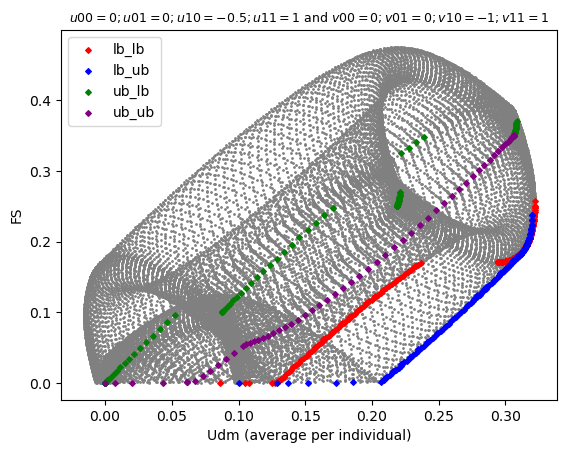

In [9]:
## plot the Pareto frontiers of the 4 combinations 
plt.scatter(df_results.U_avg, df_results.FS, s=1, color='grey')
plt.scatter(df_paretoset_lb_lb.U_avg, df_paretoset_lb_lb.FS, s=8, marker='D', color = 'red', label = 'lb_lb')
plt.scatter(df_paretoset_lb_ub.U_avg, df_paretoset_lb_ub.FS, s=8, marker='D', color = 'blue', label = 'lb_ub')
plt.scatter(df_paretoset_ub_lb.U_avg, df_paretoset_ub_lb.FS, s=8, marker='D', color = 'green', label = 'ub_lb')
plt.scatter(df_paretoset_ub_ub.U_avg, df_paretoset_ub_ub.FS, s=8, marker='D', color = 'purple', label = 'ub_ub')
plt.legend()
plt.xlabel('Udm (average per individual)')
plt.ylabel('FS')
plt.title(fr'$u00={u00};u01={u01};u10={u10};u11={u11}$ and $v00={v00};v01={v01};v10={v10};v11={v11}$', fontsize = 9)
plt.show()